# Anchors, NMS, métricas y funciones de pérdida
| IA 5.2 Computer Vision
| FCEIA - UNR

En esta práctica construimos **a mano** cada pieza que un detector de objetos usa entre los *features* del backbone y las cajas que vemos en pantalla, y después la contrastamos con la versión de la librería (`torchvision`, `torchmetrics`, `scikit-learn`).

Teoría: [`colab/class_3_Key_Concepts_for_Deep_Learning_CV.ipynb`](../colab/class_3_Key_Concepts_for_Deep_Learning_CV.ipynb) · [Abrir en Colab](https://colab.research.google.com/github/EzequielMatiasArevalo/tuia-computer-vision/blob/main/colab/class_3_Key_Concepts_for_Deep_Learning_CV.ipynb)

| # | Bloque | Pregunta que responde |
|---|---|---|
| 1 | **IoU** | ¿Cómo medimos cuánto se parecen dos cajas? |
| 2 | **Anchors** | ¿Cómo se generan, se asignan a los objetos y se codifican los offsets? ¿Qué cambia en un detector *anchor-free*? |
| 3 | **RoI Pool vs RoI Align** | ¿Qué error introduce la cuantización y cómo la evita RoI Align? |
| 4 | **NMS** | ¿Cómo pasamos de cientos de cajas candidatas a una por objeto? |
| 5 | **Métricas** | ¿Qué miden accuracy, precision, recall, F1, mAP@50 y mAP@[50:95]? |
| 6 | **Pérdidas** | ¿Por qué focal loss y por qué IoU → GIoU → DIoU → CIoU? |

Al final hay **cuatro ejercicios** para completar.

> **Corre en CPU sin problema.** No hace falta GPU: todo trabaja con cajas sintéticas y mapas de features chicos.

---
## Instalación

In [1]:
# Ejecutar una sola vez (en Colab torch, torchvision, matplotlib y scikit-learn ya vienen instalados)
# !pip install torchmetrics pycocotools -q

## Librerías

In [2]:
import math
import time

import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import box_iou, nms, batched_nms, roi_pool, roi_align

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch: {torch.__version__} | torchvision: {torchvision.__version__}")

PyTorch: 2.12.0+cpu | torchvision: 0.27.0+cpu


Dos funciones auxiliares para dibujar cajas en formato `xyxy` (`x1, y1, x2, y2`), el formato que usamos en toda la práctica. Ojo con el eje `y`: en imágenes crece **hacia abajo**, por eso lo invertimos en el gráfico.

In [3]:
def dibujar_cajas(ax, cajas, color="lime", textos=None, lw=2, ls="-"):
    """Dibuja cajas xyxy sobre un eje de matplotlib."""
    for i, b in enumerate(cajas):
        x1, y1, x2, y2 = [float(v) for v in b]
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                                       edgecolor=color, linewidth=lw, linestyle=ls))
        if textos is not None:
            ax.text(x1 + 2, y1 + 10, textos[i], color=color, fontsize=8)


def lienzo(ax, ancho, alto, titulo=""):
    """Eje con origen arriba a la izquierda, como una imagen."""
    ax.set_xlim(0, ancho)
    ax.set_ylim(alto, 0)
    ax.set_aspect("equal")
    ax.set_title(titulo, fontsize=10)
    ax.grid(alpha=0.2)

---
# 1. IoU desde cero

$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}$$

Es la pieza más reusada de todo el resto de la práctica: la usan la **asignación de anchors**, **NMS**, el **matching de las métricas** y las **pérdidas** de caja. La implementamos vectorizada: dado un conjunto `a` de `N` cajas y un conjunto `b` de `M` cajas, devuelve la matriz `(N, M)` con todos los pares.

Los pasos son: (1) esquina superior-izquierda de la intersección = **máximo** de las `x1, y1`; (2) esquina inferior-derecha = **mínimo** de las `x2, y2`; (3) si las cajas no se tocan, ancho o alto dan negativo, así que hacemos `clamp(min=0)`; (4) unión = suma de áreas − intersección.

In [4]:
def area_cajas(cajas):
    """Área de cajas xyxy (N, 4) -> (N,)."""
    return (cajas[:, 2] - cajas[:, 0]).clamp(min=0) * (cajas[:, 3] - cajas[:, 1]).clamp(min=0)


def iou_matriz(a, b):
    """IoU entre todas las cajas de `a` (N, 4) y de `b` (M, 4) -> matriz (N, M)."""
    sup_izq = torch.maximum(a[:, None, :2], b[None, :, :2])   # (N, M, 2)
    inf_der = torch.minimum(a[:, None, 2:], b[None, :, 2:])   # (N, M, 2)
    wh = (inf_der - sup_izq).clamp(min=0)                      # 0 si no se tocan
    inter = wh[..., 0] * wh[..., 1]
    union = area_cajas(a)[:, None] + area_cajas(b)[None, :] - inter
    return inter / union.clamp(min=1e-9)

Cuatro situaciones típicas, y verificación contra `torchvision.ops.box_iou`:

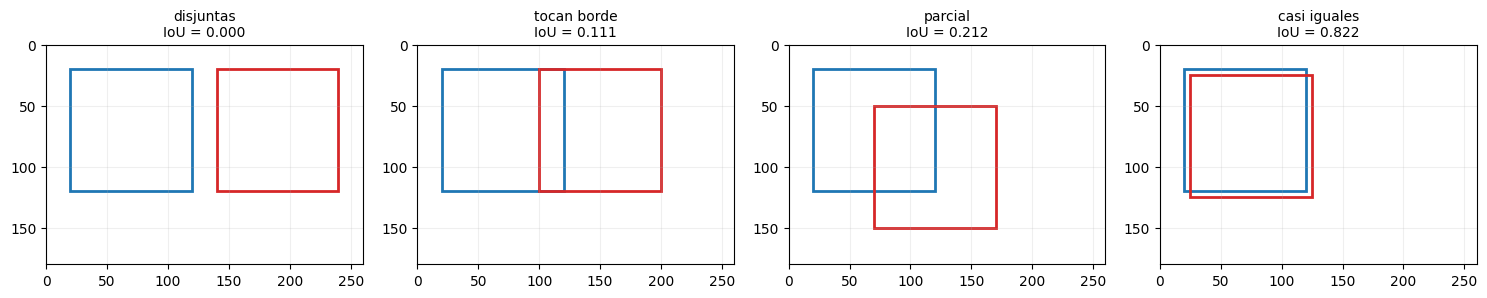

iou_matriz == box_iou en 50x40 pares: True


In [5]:
A = torch.tensor([[20., 20., 120., 120.]])
casos = {
    "disjuntas":    [140., 20., 240., 120.],
    "tocan borde":  [100., 20., 200., 120.],
    "parcial":      [70., 50., 170., 150.],
    "casi iguales": [25., 25., 125., 125.],
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (nombre, caja) in zip(axes, casos.items()):
    B = torch.tensor([caja])
    iou = iou_matriz(A, B).item()
    lienzo(ax, 260, 180, f"{nombre}\nIoU = {iou:.3f}")
    dibujar_cajas(ax, A, "tab:blue")
    dibujar_cajas(ax, B, "tab:red")
    assert abs(iou - box_iou(A, B).item()) < 1e-6
plt.tight_layout()
plt.show()

# Verificación masiva contra la librería, con cajas aleatorias
xy = torch.rand(50, 2) * 200
a = torch.cat([xy, xy + torch.rand(50, 2) * 100 + 5], dim=1)
xy = torch.rand(40, 2) * 200
b = torch.cat([xy, xy + torch.rand(40, 2) * 100 + 5], dim=1)
print("iou_matriz == box_iou en 50x40 pares:", torch.allclose(iou_matriz(a, b), box_iou(a, b), atol=1e-6))

---
# 2. Anchor boxes

Un detector basado en anchors **no predice cajas desde cero**: coloca un conjunto fijo de cajas de referencia en cada posición del mapa de features y aprende a *corregirlas*. Esta sección recorre el ciclo completo:

1. **Generar** la grilla de anchors.
2. **Asignar** cada anchor a un objeto real (positivo / negativo / ignorar) usando IoU.
3. **Codificar** el objeto real como offsets relativos al anchor (lo que la red aprende a predecir) y **decodificar** la predicción.
4. Ver cómo cambia todo con un detector **anchor-free**.

## 2.1 Generar la grilla

Cada celda del mapa de features corresponde a un cuadrado de `stride × stride` píxeles de la imagen. En el centro de cada celda ponemos `K = escalas × ratios` anchors. Definimos `ratio = alto / ancho` y conservamos el área `escala²`:

$$w = \frac{s}{\sqrt{r}} \qquad h = s\sqrt{r} \qquad \Rightarrow \qquad w\cdot h = s^2, \quad h/w = r$$

Mapa de features 8x8 x 9 anchors por celda = 576 anchors


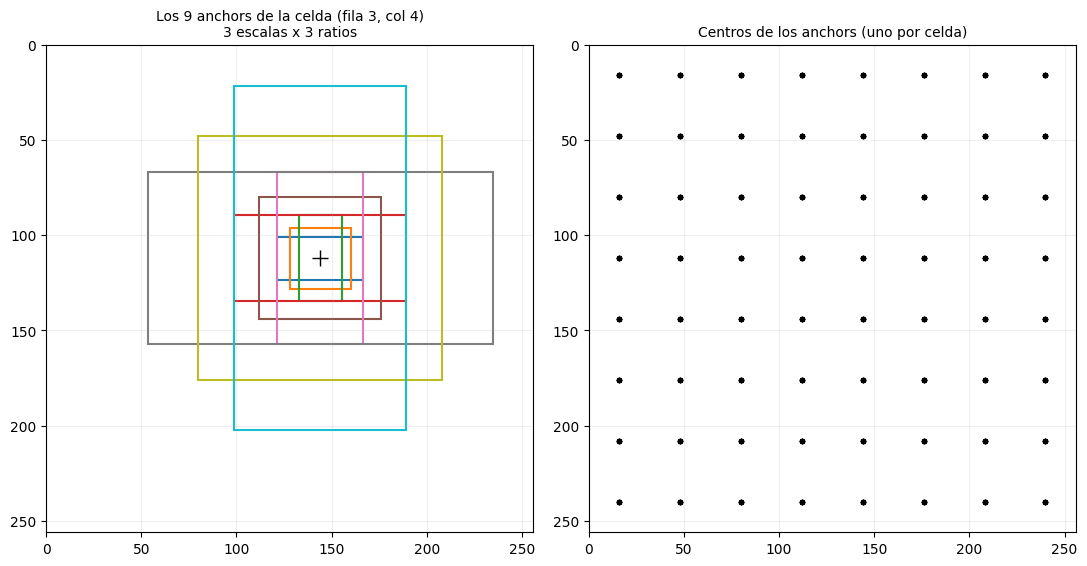

In [6]:
def generar_anchors(alto_fm, ancho_fm, stride, escalas=(32, 64, 128), ratios=(0.5, 1.0, 2.0)):
    """Grilla de anchors xyxy en coordenadas de la imagen. Orden: (fila, columna, anchor)."""
    # Una plantilla por (escala, ratio), centrada en el origen
    plantillas = []
    for s in escalas:
        for r in ratios:
            w, h = s / math.sqrt(r), s * math.sqrt(r)
            plantillas.append([-w / 2, -h / 2, w / 2, h / 2])
    plantillas = torch.tensor(plantillas)                       # (K, 4)

    # Centro de cada celda del mapa de features, en píxeles de la imagen
    cx = (torch.arange(ancho_fm) + 0.5) * stride
    cy = (torch.arange(alto_fm) + 0.5) * stride
    cy, cx = torch.meshgrid(cy, cx, indexing="ij")
    centros = torch.stack([cx, cy, cx, cy], dim=-1).reshape(-1, 1, 4)   # (H*W, 1, 4)

    return (centros + plantillas[None]).reshape(-1, 4)          # (H*W*K, 4)


IMG, STRIDE = 256, 32
FM = IMG // STRIDE                                              # mapa de 8 x 8
anchors = generar_anchors(FM, FM, STRIDE)
print(f"Mapa de features {FM}x{FM} x 9 anchors por celda = {len(anchors)} anchors")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# Izquierda: los 9 anchors de una sola celda
celda = (3 * FM + 4) * 9
lienzo(axes[0], IMG, IMG, "Los 9 anchors de la celda (fila 3, col 4)\n3 escalas x 3 ratios")
colores = plt.cm.tab10(np.linspace(0, 1, 9))
for k in range(9):
    dibujar_cajas(axes[0], anchors[celda + k:celda + k + 1], colores[k], lw=1.5)
axes[0].plot([(4 + .5) * STRIDE], [(3 + .5) * STRIDE], "k+", ms=12)

# Derecha: centros de todas las celdas
lienzo(axes[1], IMG, IMG, "Centros de los anchors (uno por celda)")
centros = (anchors[:, :2] + anchors[:, 2:]) / 2
axes[1].scatter(centros[:, 0], centros[:, 1], s=8, c="k")
plt.tight_layout()
plt.show()

> **Nota:** con 8×8 celdas y 9 anchors ya son 576 candidatos para una imagen de 256×256. Un detector real con FPN (varios niveles) llega fácil a decenas de miles: por eso después hace falta **NMS** y por eso el desbalance positivo/negativo es un problema (Sección 6).

## 2.2 Asignar anchors a objetos (reglas del RPN de Faster R-CNN)

Definimos dos objetos reales: uno grande y uno **chico**. Las reglas, aplicadas en este orden:

1. **Max-IoU:** para cada objeto, el anchor con **mayor** IoU es positivo *aunque no llegue al umbral*.
2. **Umbral:** todo anchor con IoU > 0.7 contra algún objeto es positivo.
3. **Negativo:** IoU < 0.3 contra todos los objetos.
4. **Ignorar:** lo que queda en el medio no aporta pérdida.

Para ver por qué existe la regla 1 implementamos la asignación con un interruptor que la activa o desactiva.

In [7]:
def asignar_anchors(anchors, gt, umbral_pos=0.7, umbral_neg=0.3, usar_max_iou=True):
    """Etiqueta cada anchor: 1 = positivo, 0 = negativo, -1 = ignorar.

    Devuelve (etiquetas, indice_gt_asignado, iou_maximo) con un valor por anchor.
    """
    iou = iou_matriz(anchors, gt)                 # (A, G)
    iou_max, gt_idx = iou.max(dim=1)              # mejor objeto para cada anchor

    etiquetas = torch.full((len(anchors),), -1, dtype=torch.long)   # por defecto: ignorar
    etiquetas[iou_max < umbral_neg] = 0
    etiquetas[iou_max > umbral_pos] = 1

    if usar_max_iou:
        # El mejor anchor de cada objeto es positivo SIEMPRE, aunque no llegue al umbral
        mejor_anchor = iou.argmax(dim=0)          # (G,)
        etiquetas[mejor_anchor] = 1
        gt_idx[mejor_anchor] = torch.arange(len(gt))
    return etiquetas, gt_idx, iou_max


gts = torch.tensor([[60., 50., 190., 200.],     # objeto grande
                    [200., 30., 222., 50.]])    # objeto chico (22 x 20 px)

for usar in (False, True):
    etiq, gt_idx, iou_max = asignar_anchors(anchors, gts, usar_max_iou=usar)
    por_gt = [int(((etiq == 1) & (gt_idx == g)).sum()) for g in range(len(gts))]
    print(f"regla max-IoU {'ACTIVA  ' if usar else 'INACTIVA'} -> positivos={int((etiq == 1).sum()):3d} "
          f"negativos={int((etiq == 0).sum()):3d} ignorados={int((etiq == -1).sum()):3d} | "
          f"positivos por objeto: grande={por_gt[0]}, chico={por_gt[1]}")

iou_todos = iou_matriz(anchors, gts)
print(f"\nMejor IoU posible con el objeto chico: {iou_todos[:, 1].max():.3f}  (< 0.7: ningún anchor llega al umbral)")

regla max-IoU INACTIVA -> positivos=  0 negativos=537 ignorados= 39 | positivos por objeto: grande=0, chico=0
regla max-IoU ACTIVA   -> positivos=  2 negativos=537 ignorados= 37 | positivos por objeto: grande=1, chico=1

Mejor IoU posible con el objeto chico: 0.371  (< 0.7: ningún anchor llega al umbral)


Sin la regla max-IoU el objeto chico **no genera ni un solo positivo**: la red nunca recibiría una señal para aprenderlo. Lo dibujamos:

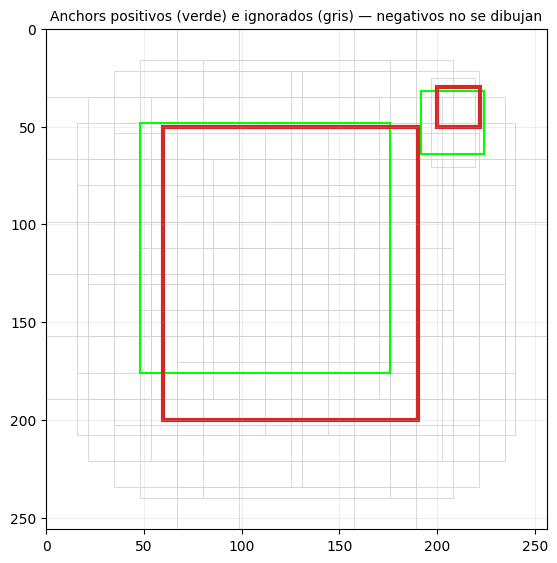

positivos: 2 | negativos: 537 | ignorados: 37


In [8]:
etiq, gt_idx, iou_max = asignar_anchors(anchors, gts)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
lienzo(ax, IMG, IMG, "Anchors positivos (verde) e ignorados (gris) — negativos no se dibujan")
dibujar_cajas(ax, anchors[etiq == -1], "lightgray", lw=0.6)
dibujar_cajas(ax, anchors[etiq == 1], "lime", lw=1.5)
dibujar_cajas(ax, gts, "tab:red", lw=3)
plt.show()

# Cuántos anchors hay de cada tipo, en una imagen típica: MUCHOS más negativos que positivos
print("positivos:", int((etiq == 1).sum()), "| negativos:", int((etiq == 0).sum()), "| ignorados:", int((etiq == -1).sum()))

> **Los umbrales son propios de cada detector**, no universales: 0.7 / 0.3 es el RPN; RetinaNet usa 0.5 / 0.4; la segunda etapa de Faster R-CNN usa un solo umbral de 0.5. Los probás en el **Ejercicio 1**.

## 2.3 Codificar y decodificar offsets

La red no predice coordenadas absolutas: predice **offsets normalizados** respecto de su anchor `a`. Para un objeto real `g` (con centro `x, y`, ancho `w` y alto `h`):

```text
tx = (gx - ax) / aw          tw = log(gw / aw)
ty = (gy - ay) / ah          th = log(gh / ah)
```

Y para decodificar una predicción `(tx, ty, tw, th)`: `bx = tx·aw + ax`, `by = ty·ah + ay`, `bw = aw·exp(tw)`, `bh = ah·exp(th)`. El `log` (y su inversa `exp`) garantiza que la red nunca pueda predecir un tamaño negativo.

In [9]:
def a_centro_tamano(cajas):
    """xyxy -> (cx, cy, w, h)."""
    w = cajas[:, 2] - cajas[:, 0]
    h = cajas[:, 3] - cajas[:, 1]
    return cajas[:, 0] + w / 2, cajas[:, 1] + h / 2, w, h


def codificar(anchors, gt):
    """Objeto real -> offsets (tx, ty, tw, th) relativos al anchor. Es el TARGET de entrenamiento."""
    ax, ay, aw, ah = a_centro_tamano(anchors)
    gx, gy, gw, gh = a_centro_tamano(gt)
    return torch.stack([(gx - ax) / aw, (gy - ay) / ah, torch.log(gw / aw), torch.log(gh / ah)], dim=1)


def decodificar(anchors, deltas):
    """Offsets predichos -> cajas xyxy."""
    ax, ay, aw, ah = a_centro_tamano(anchors)
    cx = deltas[:, 0] * aw + ax
    cy = deltas[:, 1] * ah + ay
    w = aw * torch.exp(deltas[:, 2])
    h = ah * torch.exp(deltas[:, 3])
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=1)


# Ida y vuelta sobre los anchors positivos: decodificar(codificar(gt)) debe devolver el gt
pos = etiq == 1
anchors_pos = anchors[pos]
gt_asignado = gts[gt_idx[pos]]
targets = codificar(anchors_pos, gt_asignado)
print("ida y vuelta exacta:", torch.allclose(decodificar(anchors_pos, targets), gt_asignado, atol=1e-3))
print("\nTargets de los primeros positivos (tx, ty, tw, th):")
print(targets[:4].numpy().round(3))

ida y vuelta exacta: True

Targets de los primeros positivos (tx, ty, tw, th):
[[ 0.094 -0.25  -0.375 -0.47 ]
 [ 0.102  0.102  0.016  0.159]]


**¿Por qué normalizar por el tamaño del anchor?** Un mismo error de 16 píxeles en el centro es enorme para un anchor chico y despreciable para uno grande. Con el offset normalizado la red ve exactamente eso:

In [10]:
for lado in (32., 128.):
    anchor = torch.tensor([[100., 100., 100. + lado, 100. + lado]])
    gt_desplazado = anchor + torch.tensor([[16., 0., 16., 0.]])        # mismo error: 16 px en x
    tx = codificar(anchor, gt_desplazado)[0, 0].item()
    print(f"anchor de {lado:>5.0f} px, error de 16 px en x  ->  tx = {tx:.3f}")

anchor de    32 px, error de 16 px en x  ->  tx = 0.500
anchor de   128 px, error de 16 px en x  ->  tx = 0.125


## 2.4 Anchor-free: distancias a los cuatro bordes

Un detector anchor-free (FCOS, YOLOv8/11, ...) descarta los anchors. Cada **punto** del mapa de features predice `(l, t, r, b)`: a qué distancia están de él los bordes izquierdo, superior, derecho e inferior del objeto.

```text
x1 = px − l      y1 = py − t
x2 = px + r      y2 = py + b
```

Desaparecen las escalas, los ratios y los umbrales de IoU. Pero algo tiene que decidir **qué puntos son positivos**. La estrategia más simple (*center sampling*, FCOS) es: un punto es positivo si cae dentro de una vecindad del centro del objeto.

Puntos dentro del objeto: 16 | positivos con center sampling: 9
Ida y vuelta (l,t,r,b) -> caja: True


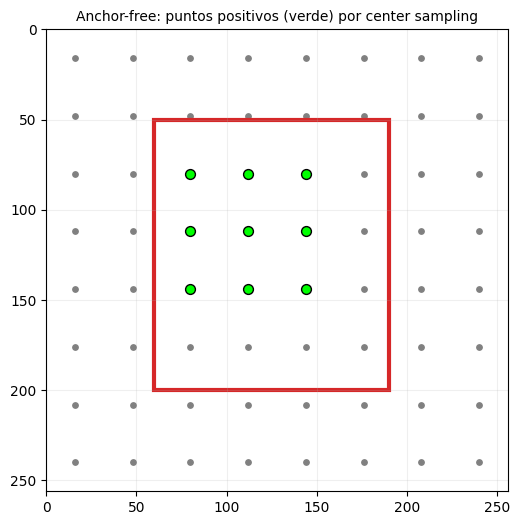

In [11]:
def ltrb_desde_puntos(puntos, cajas):
    """Distancias (l, t, r, b) desde cada punto (N, 2) hasta los bordes de su caja (N, 4)."""
    return torch.stack([puntos[:, 0] - cajas[:, 0], puntos[:, 1] - cajas[:, 1],
                        cajas[:, 2] - puntos[:, 0], cajas[:, 3] - puntos[:, 1]], dim=1)


def caja_desde_ltrb(puntos, ltrb):
    return torch.stack([puntos[:, 0] - ltrb[:, 0], puntos[:, 1] - ltrb[:, 1],
                        puntos[:, 0] + ltrb[:, 2], puntos[:, 1] + ltrb[:, 3]], dim=1)


# Un punto por celda del mapa de features (los mismos centros de antes)
puntos = ((torch.stack(torch.meshgrid(torch.arange(FM), torch.arange(FM), indexing="ij"), dim=-1)
           .reshape(-1, 2).flip(1) + 0.5) * STRIDE).float()          # (64, 2) en orden (x, y)

objeto = gts[0:1]
ltrb = ltrb_desde_puntos(puntos, objeto.expand(len(puntos), 4))
dentro = (ltrb > 0).all(dim=1)                                        # el punto cae dentro del objeto

centro = (objeto[0, :2] + objeto[0, 2:]) / 2
cerca_del_centro = (puntos - centro).abs().max(dim=1).values <= 1.5 * STRIDE     # radio de center sampling
positivos = dentro & cerca_del_centro

print(f"Puntos dentro del objeto: {int(dentro.sum())} | positivos con center sampling: {int(positivos.sum())}")
print("Ida y vuelta (l,t,r,b) -> caja:", torch.allclose(caja_desde_ltrb(puntos, ltrb), objeto.expand(len(puntos), 4)))

fig, ax = plt.subplots(figsize=(6, 6))
lienzo(ax, IMG, IMG, "Anchor-free: puntos positivos (verde) por center sampling")
ax.scatter(puntos[~positivos, 0], puntos[~positivos, 1], c="gray", s=15)
ax.scatter(puntos[positivos, 0], puntos[positivos, 1], c="lime", s=50, edgecolor="k")
dibujar_cajas(ax, objeto, "tab:red", lw=3)
plt.show()

---
# 3. RoI Pooling vs RoI Align

El RPN propone cajas en **coordenadas de la imagen**, pero el head de clasificación trabaja sobre el **mapa de features**, que tiene menor resolución (dividido por el `stride` del backbone). Para cada propuesta hay que recortar un parche de tamaño fijo (p. ej. 7×7) del mapa. Hay dos formas de hacerlo:

- **RoI Pool** redondea las coordenadas flotantes a la grilla entera del mapa (*cuantización*).
- **RoI Align** no redondea nada: muestrea el mapa en posiciones flotantes con **interpolación bilineal**.

## 3.1 Cuánto error mete la cuantización

Con `stride = 16` una propuesta `x = 37` cae en `37 / 16 = 2.31` del mapa. RoI Pool lo redondea a `2`: al volver a la imagen es un error de `(2 - 2.31) × 16 ≈ -5 px`. Hasta **8 px** de desalineación por coordenada.

In [12]:
STRIDE_FM = 16
propuestas = torch.tensor([[37., 53., 213., 149.],
                           [100., 20., 180., 90.],
                           [321., 190., 417., 271.]])

en_mapa = propuestas / STRIDE_FM
cuantizado = en_mapa.round()                                   # lo que hace RoI Pool
error_px = (cuantizado - en_mapa) * STRIDE_FM                  # de vuelta a píxeles de la imagen

print("propuesta (px)          -> en el mapa            -> redondeado          | error (px)")
for p, m, q, e in zip(propuestas, en_mapa, cuantizado, error_px):
    print(f"{p.tolist()} -> {[round(v, 2) for v in m.tolist()]} -> {q.int().tolist()} | {[round(v, 1) for v in e.tolist()]}")
print(f"\nError absoluto máximo posible por coordenada: {STRIDE_FM / 2:.0f} px | observado: {error_px.abs().max():.1f} px")

propuesta (px)          -> en el mapa            -> redondeado          | error (px)
[37.0, 53.0, 213.0, 149.0] -> [2.31, 3.31, 13.31, 9.31] -> [2, 3, 13, 9] | [-5.0, -5.0, -5.0, -5.0]
[100.0, 20.0, 180.0, 90.0] -> [6.25, 1.25, 11.25, 5.62] -> [6, 1, 11, 6] | [-4.0, -4.0, -4.0, 6.0]
[321.0, 190.0, 417.0, 271.0] -> [20.06, 11.88, 26.06, 16.94] -> [20, 12, 26, 17] | [-1.0, 2.0, -1.0, 1.0]

Error absoluto máximo posible por coordenada: 8 px | observado: 6.0 px


Y RoI Pool cuantiza **una segunda vez**: los bins de la grilla 7×7 también se redondean a enteros. Para un objeto grande son un par de píxeles de imagen, pero para un objeto chico o para segmentación a nivel de píxel (Mask R-CNN) es fatal.

## 3.2 Reproducir la diferencia: deslizar la propuesta de a poco

Experimento: tomamos un mapa de features suave y **desplazamos la propuesta fracciones de celda**. Un buen operador debería cambiar su salida *de forma continua*. Miramos el bin central del parche 7×7:

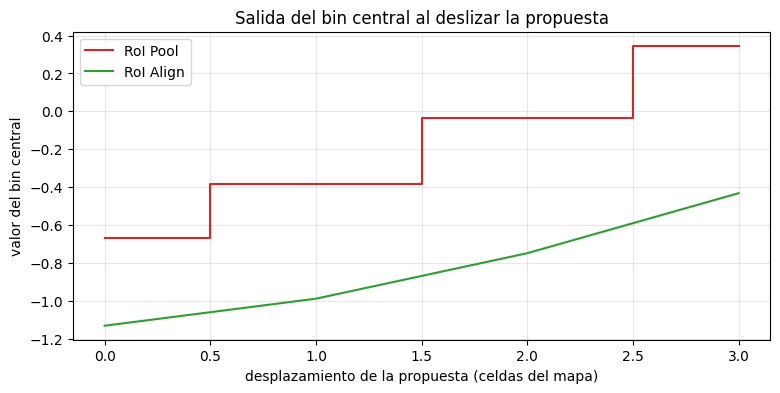

valores distintos en 61 posiciones -> RoI Pool: 4 | RoI Align: 61


In [13]:
# Mapa de features de 1 canal, suave (senos y cosenos)
ys, xs = torch.meshgrid(torch.arange(32.), torch.arange(32.), indexing="ij")
mapa = (torch.sin(xs / 3.0) + torch.cos(ys / 4.0) + 0.05 * xs)[None, None]      # (1, 1, 32, 32)

base = torch.tensor([[0., 8., 8., 22., 22.]])          # [indice_en_batch, x1, y1, x2, y2] en coordenadas del mapa
desplazamientos = torch.linspace(0, 3, 61)              # de 0 a 3 celdas, en pasos de 0.05

vals_pool, vals_align = [], []
for d in desplazamientos:
    roi = base.clone()
    roi[:, [1, 3]] += d                                 # desplazamos en x
    vals_pool.append(roi_pool(mapa, roi, (7, 7), spatial_scale=1.0)[0, 0, 3, 3].item())
    vals_align.append(roi_align(mapa, roi, (7, 7), spatial_scale=1.0, sampling_ratio=2, aligned=True)[0, 0, 3, 3].item())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(desplazamientos, vals_pool, drawstyle="steps-post", label="RoI Pool", color="tab:red")
ax.plot(desplazamientos, vals_align, label="RoI Align", color="tab:green")
ax.set_xlabel("desplazamiento de la propuesta (celdas del mapa)")
ax.set_ylabel("valor del bin central")
ax.set_title("Salida del bin central al deslizar la propuesta")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("valores distintos en 61 posiciones -> RoI Pool:", len(set(np.round(vals_pool, 6))),
      "| RoI Align:", len(set(np.round(vals_align, 6))))

Las dos curvas no están a la misma altura porque RoI Pool toma el **máximo** de cada bin y RoI Align el **promedio** de sus puntos de muestreo; lo que importa es la *forma*. RoI Pool responde a **saltos**: mueve la propuesta media celda y a veces no cambia nada, y de golpe cambia mucho. RoI Align responde de forma continua y (casi) proporcional al desplazamiento, que es lo que queremos para poder localizar con precisión sub-celda.

> **Detalle de implementación:** `aligned=True` en `torchvision.ops.roi_align` corrige un desfase de medio píxel del convenio histórico. En código nuevo conviene usarlo siempre.

---
# 4. NMS (Non-Maximum Suppression)

Un detector denso devuelve muchas cajas por objeto. NMS se queda con una:

1. Ordenar las cajas por score, de mayor a menor.
2. Quedarse con la primera (la más confiable).
3. Descartar todas las que tengan **IoU > umbral** con ella.
4. Repetir con lo que queda.

## 4.1 NMS desde cero

Reutilizamos `iou_matriz` de la Sección 1.

In [14]:
def nms_desde_cero(cajas, scores, umbral_iou=0.5):
    """NMS clase-agnóstico. Devuelve los índices de las cajas que sobreviven."""
    if cajas.numel() == 0:
        return torch.empty(0, dtype=torch.long)

    orden = scores.argsort(descending=True)
    conservar = []
    while orden.numel() > 0:
        i = orden[0]                                         # la mejor de las que quedan
        conservar.append(int(i))
        if orden.numel() == 1:
            break
        resto = orden[1:]
        iou = iou_matriz(cajas[i:i + 1], cajas[resto])[0]    # IoU de la mejor contra el resto
        orden = resto[iou <= umbral_iou]                     # nos quedamos con las que NO se le parecen
    return torch.tensor(conservar, dtype=torch.long)

Simulamos 3 objetos; el detector genera 8 cajas ruidosas por cada uno más algunos falsos positivos con score bajo. El pipeline real es: **filtrar por score → NMS**.

Cajas candidatas: 30
Tras el filtro de score > 0.5: 24
Tras NMS (IoU 0.5): 3  ->  una por objeto
Coincide con torchvision.ops.nms: True


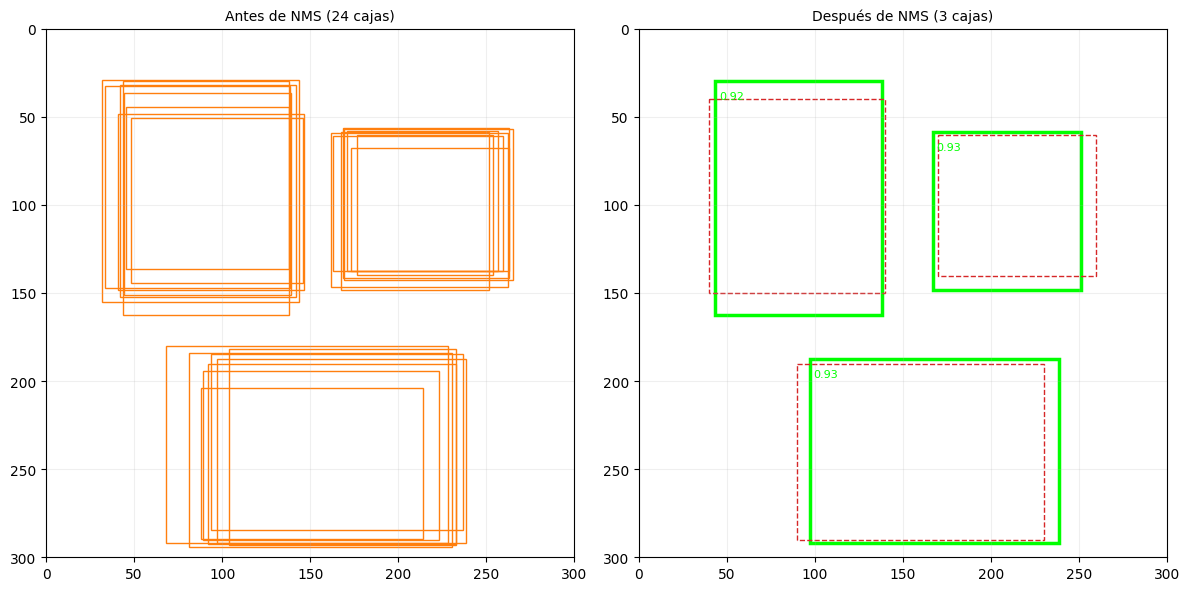

In [15]:
objetos = torch.tensor([[40., 40., 140., 150.], [170., 60., 260., 140.], [90., 190., 230., 290.]])


def simular_detecciones(objetos, n_por_objeto=8, ruido=0.06, n_falsos=6, seed=0):
    g = torch.Generator().manual_seed(seed)
    cajas, scores = [], []
    for o in objetos:
        w, h = o[2] - o[0], o[3] - o[1]
        jitter = torch.randn(n_por_objeto, 4, generator=g) * ruido * torch.stack([w, h, w, h])
        cajas.append(o + jitter)
        scores.append(0.55 + 0.4 * torch.rand(n_por_objeto, generator=g))
    xy = torch.rand(n_falsos, 2, generator=g) * 250
    cajas.append(torch.cat([xy, xy + 20 + torch.rand(n_falsos, 2, generator=g) * 60], dim=1))
    scores.append(0.05 + 0.35 * torch.rand(n_falsos, generator=g))
    return torch.cat(cajas), torch.cat(scores)


cajas_det, scores_det = simular_detecciones(objetos)
print("Cajas candidatas:", len(cajas_det))

# 1) filtro por score  ->  2) NMS
UMBRAL_SCORE = 0.5
visibles = scores_det > UMBRAL_SCORE
cajas_v, scores_v = cajas_det[visibles], scores_det[visibles]
print(f"Tras el filtro de score > {UMBRAL_SCORE}: {len(cajas_v)}")

conservar = nms_desde_cero(cajas_v, scores_v, umbral_iou=0.5)
print(f"Tras NMS (IoU 0.5): {len(conservar)}  ->  una por objeto")
print("Coincide con torchvision.ops.nms:", sorted(conservar.tolist()) == sorted(nms(cajas_v, scores_v, 0.5).tolist()))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
lienzo(axes[0], 300, 300, f"Antes de NMS ({len(cajas_v)} cajas)")
dibujar_cajas(axes[0], cajas_v, "tab:orange", lw=1)
lienzo(axes[1], 300, 300, f"Después de NMS ({len(conservar)} cajas)")
dibujar_cajas(axes[1], cajas_v[conservar], "lime", textos=[f"{s:.2f}" for s in scores_v[conservar]], lw=2.5)
dibujar_cajas(axes[1], objetos, "tab:red", lw=1, ls="--")
plt.tight_layout()
plt.show()

### El umbral de IoU es un hiperparámetro

- Umbral **bajo** (0.3): agresivo, borra cajas que se parecen poco. Riesgo: eliminar objetos **distintos** que están juntos.
- Umbral **alto** (0.7): permisivo, deja pasar duplicados.

In [16]:
for umbral in (0.1, 0.3, 0.5, 0.7, 0.9):
    n = len(nms_desde_cero(cajas_v, scores_v, umbral))
    print(f"umbral IoU = {umbral:.1f}  ->  {n:2d} detecciones (objetos reales: {len(objetos)})")

umbral IoU = 0.1  ->   3 detecciones (objetos reales: 3)
umbral IoU = 0.3  ->   3 detecciones (objetos reales: 3)
umbral IoU = 0.5  ->   3 detecciones (objetos reales: 3)
umbral IoU = 0.7  ->   6 detecciones (objetos reales: 3)
umbral IoU = 0.9  ->  22 detecciones (objetos reales: 3)


## 4.2 NMS por clase

Nuestra versión compara **todas** las cajas contra todas, sin mirar la etiqueta. Con un detector multi-clase eso es un error: una persona parada al lado de su bicicleta produce dos cajas que se superponen *y ambas son correctas*.

Lo correcto es correr un NMS **independiente por clase**. En PyTorch: `torchvision.ops.batched_nms(cajas, scores, clases, umbral)`.

In [17]:
NOMBRES = {0: "persona", 1: "bicicleta"}
cajas_mc = torch.tensor([[30., 30., 90., 150.],       # persona
                         [35., 55., 100., 155.]])     # bicicleta
scores_mc = torch.tensor([0.95, 0.88])
clases_mc = torch.tensor([0, 1])

print(f"IoU entre las dos cajas: {iou_matriz(cajas_mc[:1], cajas_mc[1:]).item():.3f}  (> 0.5)")


def nms_por_clase(cajas, scores, clases, umbral_iou=0.5):
    """Un NMS por cada clase, por separado."""
    conservar = []
    for c in clases.unique():
        idx = torch.where(clases == c)[0]
        conservar.append(idx[nms_desde_cero(cajas[idx], scores[idx], umbral_iou)])
    return torch.cat(conservar)


agnostico = nms_desde_cero(cajas_mc, scores_mc, 0.5)
por_clase = nms_por_clase(cajas_mc, scores_mc, clases_mc, 0.5)
lib = batched_nms(cajas_mc, scores_mc, clases_mc, 0.5)

print("agnóstico :", [NOMBRES[int(clases_mc[i])] for i in agnostico], "  <- perdimos la bicicleta")
print("por clase :", [NOMBRES[int(clases_mc[i])] for i in por_clase])
print("batched_nms de torchvision coincide:", sorted(por_clase.tolist()) == sorted(lib.tolist()))

IoU entre las dos cajas: 0.617  (> 0.5)
agnóstico : ['persona']   <- perdimos la bicicleta
por clase : ['persona', 'bicicleta']
batched_nms de torchvision coincide: True


## 4.3 Velocidad

Nuestra versión hace un bucle de Python por cada caja conservada. `torchvision.ops.nms` está implementado en C++/CUDA:

In [18]:
torch.manual_seed(0)
N = 2000
xy = torch.rand(N, 2) * 900
cajas_grandes = torch.cat([xy, xy + 20 + torch.rand(N, 2) * 80], dim=1)
scores_grandes = torch.rand(N)

t0 = time.perf_counter(); k1 = nms_desde_cero(cajas_grandes, scores_grandes, 0.5); t_mio = time.perf_counter() - t0
t0 = time.perf_counter(); k2 = nms(cajas_grandes, scores_grandes, 0.5); t_lib = time.perf_counter() - t0

print(f"{N} cajas | desde cero: {t_mio * 1000:7.1f} ms ({len(k1)} conservadas) | torchvision: {t_lib * 1000:6.1f} ms ({len(k2)} conservadas)")
print("Mismo resultado:", sorted(k1.tolist()) == sorted(k2.tolist()))

2000 cajas | desde cero:   506.3 ms (1535 conservadas) | torchvision:    6.5 ms (1535 conservadas)
Mismo resultado: True


> **NMS ya no es universal.** Es un heurístico que se agrega *después* de la red, no es diferenciable y agrega un hiperparámetro. Los detectores basados en **DETR** no lo necesitan (el matching húngaro asigna un solo *query* por objeto), y YOLOv10 / YOLO26 tampoco por defecto. En el **Ejercicio 2** implementás una variante, **Soft-NMS**.

---
# 5. Métricas

## 5.1 Clasificación: accuracy, precision, recall y F1

Todas salen de los cuatro conteos de la **matriz de confusión** de una clase positiva:

| | predice positivo | predice negativo |
|---|---|---|
| **real positivo** | TP | FN |
| **real negativo** | FP | TN |

$$\text{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN} \quad \text{Precision}=\frac{TP}{TP+FP} \quad \text{Recall}=\frac{TP}{TP+FN} \quad F1=2\,\frac{P\cdot R}{P+R}$$

In [19]:
def metricas_clasificacion(y_real, y_pred):
    """Accuracy, precision, recall y F1 para la clase positiva (1), calculados a mano."""
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    tp = int(((y_pred == 1) & (y_real == 1)).sum())
    fp = int(((y_pred == 1) & (y_real == 0)).sum())
    fn = int(((y_pred == 0) & (y_real == 1)).sum())
    tn = int(((y_pred == 0) & (y_real == 0)).sum())
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


# Ejemplo de la teoría (spam): 40 TP, 10 FN, 5 FP, 45 TN
y_real = np.array([1] * 50 + [0] * 50)
y_pred = np.array([1] * 40 + [0] * 10 + [1] * 5 + [0] * 45)
print({k: round(v, 3) for k, v in metricas_clasificacion(y_real, y_pred).items()})

{'TP': 40, 'FP': 5, 'FN': 10, 'TN': 45, 'accuracy': 0.85, 'precision': 0.889, 'recall': 0.8, 'f1': 0.842}


### La trampa de accuracy con clases desbalanceadas

Dataset con 1000 imágenes y solo **50 positivas (5 %)**. Comparamos dos modelos:

- **Modelo A:** ignora la imagen y **siempre** responde "negativo".
- **Modelo B:** un modelo real, que acierta la mayoría de los positivos pero se equivoca un poco.

In [20]:
rng = np.random.default_rng(0)
y_real = np.array([1] * 50 + [0] * 950)

y_A = np.zeros(1000, dtype=int)                                   # siempre negativo
y_B = y_real.copy()
y_B[rng.choice(50, 10, replace=False)] = 0                        # se le escapan 10 positivos (FN)
y_B[50 + rng.choice(950, 40, replace=False)] = 1                  # 40 falsas alarmas (FP)

filas = {"Modelo A (siempre negativo)": metricas_clasificacion(y_real, y_A),
         "Modelo B (real)": metricas_clasificacion(y_real, y_B)}
print(f"{'':<30}{'accuracy':>10}{'precision':>11}{'recall':>9}{'F1':>7}")
for nombre, m in filas.items():
    print(f"{nombre:<30}{m['accuracy']:>10.3f}{m['precision']:>11.3f}{m['recall']:>9.3f}{m['f1']:>7.3f}")

# Verificación contra scikit-learn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
p, r, f, _ = precision_recall_fscore_support(y_real, y_B, average="binary", zero_division=0)
print(f"\nscikit-learn (modelo B): accuracy={accuracy_score(y_real, y_B):.3f} precision={p:.3f} recall={r:.3f} F1={f:.3f}")

                                accuracy  precision   recall     F1
Modelo A (siempre negativo)        0.950      0.000    0.000  0.000
Modelo B (real)                    0.950      0.500    0.800  0.615



scikit-learn (modelo B): accuracy=0.950 precision=0.500 recall=0.800 F1=0.615


Los dos modelos tienen **exactamente el mismo accuracy (95 %)**, pero el A **no detecta absolutamente nada** (recall 0, F1 0) y el B sí. Con clases desbalanceadas el accuracy premia al que ignora la clase rara; recall y F1 lo delatan. (Y precision y recall cuentan historias distintas: B encuentra el 80 % de los positivos, pero solo la mitad de sus alarmas son reales.)

## 5.2 Detección: AP y mAP desde cero

En detección cada predicción es un par *(clase, caja)* con un score, así que hace falta una definición de "acierto":

- Una predicción es **TP** si tiene la clase correcta e **IoU ≥ τ** con un objeto real que **no fue ya emparejado**. Si no, es **FP**.
- Los objetos reales sin predicción son **FN**.

Cómo se construye el **AP** de una clase a un umbral τ:

1. Juntar las predicciones de esa clase de **todas las imágenes** en una sola lista (nunca imagen por imagen).
2. Ordenarlas por score, de mayor a menor.
3. Recorrer la lista marcando TP / FP con matching voraz. En cada punto tenemos `precision` y `recall` **acumulados**: eso dibuja la curva PR.
4. Hacer la curva monótona decreciente (la *envolvente*) y promediar la precisión en **101 niveles de recall** (0.00, 0.01, ..., 1.00), como hace COCO.

**mAP@50** promedia el AP sobre las clases con τ = 0.5. **mAP@[50:95]** promedia además sobre τ = 0.50, 0.55, ..., 0.95.

Primero, un dataset sintético: 30 imágenes, 3 clases. El "detector" encuentra ~85 % de los objetos, con cajas más o menos prolijas (mejor caja → mayor score), a veces se equivoca de clase y agrega falsos positivos.

In [21]:
def simular_dataset(n_imgs=30, n_clases=3, seed=1):
    rng = np.random.default_rng(seed)
    gts, preds = [], []
    for _ in range(n_imgs):
        n_obj = int(rng.integers(1, 5))
        xy = rng.uniform(10, 250, (n_obj, 2))
        cajas = np.concatenate([xy, xy + rng.uniform(40, 150, (n_obj, 2))], axis=1)
        clases = rng.integers(0, n_clases, n_obj)
        gts.append({"boxes": torch.tensor(cajas, dtype=torch.float32), "labels": torch.tensor(clases, dtype=torch.int64)})

        pb, ps, pl = [], [], []
        for c, cl in zip(cajas, clases):
            if rng.random() < 0.85:                                    # el detector lo encuentra
                sigma = rng.choice([0.03, 0.08, 0.15])                 # calidad de la caja
                w, h = c[2] - c[0], c[3] - c[1]
                pb.append(c + rng.normal(0, sigma, 4) * np.array([w, h, w, h]))
                ps.append(np.clip(0.95 - 2.5 * sigma + rng.normal(0, 0.05), 0.05, 0.99))
                pl.append(cl if rng.random() < 0.92 else rng.integers(0, n_clases))
        for _ in range(int(rng.integers(0, 4))):                       # falsos positivos
            xy = rng.uniform(10, 300, 2)
            pb.append(np.concatenate([xy, xy + rng.uniform(30, 120, 2)]))
            ps.append(rng.uniform(0.05, 0.6))
            pl.append(rng.integers(0, n_clases))
        preds.append({"boxes": torch.tensor(np.array(pb), dtype=torch.float32).reshape(-1, 4),
                      "scores": torch.tensor(ps, dtype=torch.float32),
                      "labels": torch.tensor(pl, dtype=torch.int64)})
    return preds, gts


N_CLASES = 3
preds, gts_det = simular_dataset(n_clases=N_CLASES)
print("Imágenes:", len(gts_det), "| objetos reales:", sum(len(g["labels"]) for g in gts_det),
      "| predicciones:", sum(len(p["labels"]) for p in preds))

Imágenes: 30 | objetos reales: 72 | predicciones: 108


In [22]:
def ap_una_clase(preds, gts, clase, umbral_iou):
    """AP de UNA clase a UN umbral de IoU. Junta las detecciones de todas las imágenes."""
    dets, n_gt = [], 0
    for i, (p, g) in enumerate(zip(preds, gts)):
        m = p["labels"] == clase
        dets += [(s.item(), i, b) for s, b in zip(p["scores"][m], p["boxes"][m])]
        n_gt += int((g["labels"] == clase).sum())
    if n_gt == 0:
        return {"ap": float("nan")}

    dets.sort(key=lambda d: -d[0])                                        # de mayor a menor score
    usado = {i: torch.zeros(int((g["labels"] == clase).sum()), dtype=torch.bool) for i, g in enumerate(gts)}

    tp = np.zeros(len(dets))
    for k, (score, i, caja) in enumerate(dets):
        gt_clase = gts[i]["boxes"][gts[i]["labels"] == clase]
        if len(gt_clase) == 0:
            continue                                                       # FP: no hay objetos de esa clase acá
        iou = iou_matriz(caja[None], gt_clase)[0]
        iou[usado[i]] = -1                                                 # un objeto real se empareja una sola vez
        j = int(iou.argmax())
        if iou[j] >= umbral_iou:
            tp[k] = 1
            usado[i][j] = True

    tp_ac, fp_ac = np.cumsum(tp), np.cumsum(1 - tp)
    recall = tp_ac / n_gt
    precision = tp_ac / (tp_ac + fp_ac)

    envolvente = precision.copy()                                          # precisión monótona decreciente
    for k in range(len(envolvente) - 2, -1, -1):
        envolvente[k] = max(envolvente[k], envolvente[k + 1])

    # 101 niveles de recall (COCO). En float32, igual que torchmetrics: con float64 los empates exactos
    # (p. ej. recall = 7/25 = 0.28) se resuelven distinto y el AP cambia en el 3er decimal.
    niveles = torch.linspace(0, 1, 101).double().numpy()
    idx = np.searchsorted(recall, niveles, side="left")
    ap = float(np.mean([envolvente[j] if j < len(envolvente) else 0.0 for j in idx]))
    return {"ap": ap, "precision": precision, "recall": recall, "scores": np.array([d[0] for d in dets]),
            "envolvente": envolvente}


UMBRALES = np.round(np.arange(0.50, 0.96, 0.05), 2)                        # 0.50, 0.55, ..., 0.95

def tabla_ap(preds, gts, n_clases, umbrales=UMBRALES):
    """Matriz AP[umbral, clase]."""
    return np.array([[ap_una_clase(preds, gts, c, t)["ap"] for c in range(n_clases)] for t in umbrales])

AP = tabla_ap(preds, gts_det, N_CLASES)
print("AP@50 por clase        :", AP[0].round(3))
print(f"mAP@50                 : {np.nanmean(AP[0]):.4f}")
print(f"mAP@[50:95] (10 umbrales): {np.nanmean(AP):.4f}")

AP@50 por clase        : [0.729 0.686 0.643]
mAP@50                 : 0.6863
mAP@[50:95] (10 umbrales): 0.4370


Verificamos contra `torchmetrics`, que usa el mismo código de evaluación que COCO (`pycocotools`):

In [23]:
try:
    from torchmetrics.detection import MeanAveragePrecision
    metrica = MeanAveragePrecision(iou_type="bbox")
    metrica.update(preds, gts_det)
    res = metrica.compute()
    print(f"{'':<14}{'desde cero':>12}{'torchmetrics':>14}")
    print(f"{'mAP@50':<14}{np.nanmean(AP[0]):>12.4f}{res['map_50'].item():>14.4f}")
    print(f"{'mAP@[50:95]':<14}{np.nanmean(AP):>12.4f}{res['map'].item():>14.4f}")
except ImportError:
    print("Falta torchmetrics/pycocotools:  !pip install torchmetrics pycocotools")

                desde cero  torchmetrics
mAP@50              0.6863        0.6863
mAP@[50:95]         0.4370        0.4370


Miramos las curvas PR de cada clase a IoU 0.5, y cómo cae el AP a medida que exigimos cajas más ajustadas. Dos detectores pueden tener un mAP@50 parecido y un mAP@[50:95] muy distinto si uno dibuja cajas más sueltas.

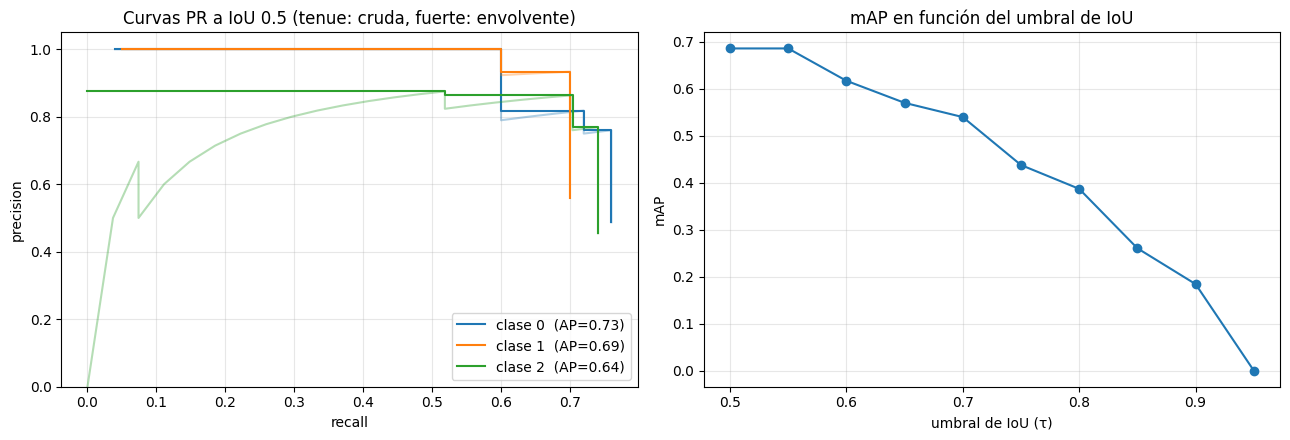

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for c in range(N_CLASES):
    r = ap_una_clase(preds, gts_det, c, 0.5)
    axes[0].plot(r["recall"], r["precision"], alpha=0.35, color=f"C{c}")
    axes[0].plot(r["recall"], r["envolvente"], color=f"C{c}", label=f"clase {c}  (AP={r['ap']:.2f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Curvas PR a IoU 0.5 (tenue: cruda, fuerte: envolvente)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(UMBRALES, np.nanmean(AP, axis=1), "o-")
axes[1].set_xlabel("umbral de IoU (τ)"); axes[1].set_ylabel("mAP")
axes[1].set_title("mAP en función del umbral de IoU")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# 6. Funciones de pérdida

Un detector entrena con una pérdida **multi-tarea**: una parte para *qué* es (clasificación) y otra para *dónde* está (regresión de la caja).

## 6.1 Clasificación: cross-entropy vs focal loss

Con `p_t` = probabilidad que el modelo le da a la clase **correcta**:

$$\mathrm{CE}(p_t) = -\log(p_t) \qquad\qquad \mathrm{FL}(p_t) = -\alpha_t\,(1-p_t)^{\gamma}\,\log(p_t)$$

El factor `(1 − p_t)^γ` apaga los ejemplos fáciles (`p_t → 1`) y con `γ = 0` la focal loss vuelve a ser la CE (ponderada por α).

In [25]:
def ce_binaria(prob, y):
    """Cross-entropy binaria por elemento. `prob` = probabilidad de la clase positiva."""
    p_t = torch.where(y == 1, prob, 1 - prob)
    return -torch.log(p_t.clamp(min=1e-12))


def focal_loss(prob, y, alfa=0.25, gamma=2.0):
    """Focal loss binaria por elemento."""
    p_t = torch.where(y == 1, prob, 1 - prob)
    alfa_t = torch.where(y == 1, torch.full_like(prob, alfa), torch.full_like(prob, 1 - alfa))
    return -alfa_t * (1 - p_t) ** gamma * torch.log(p_t.clamp(min=1e-12))


# Verificación contra torchvision (que trabaja con logits)
logits = torch.randn(1000) * 2
y = (torch.rand(1000) < 0.3).float()
mia = focal_loss(torch.sigmoid(logits), y, alfa=0.25, gamma=2.0)
lib = torchvision.ops.sigmoid_focal_loss(logits, y, alpha=0.25, gamma=2.0, reduction="none")
print("focal_loss == torchvision.ops.sigmoid_focal_loss:", torch.allclose(mia, lib, rtol=1e-3, atol=1e-5))
print("con gamma=0 y alfa=0.5 es CE/2:", torch.allclose(focal_loss(torch.sigmoid(logits), y, 0.5, 0.0), ce_binaria(torch.sigmoid(logits), y) / 2, atol=1e-6))

focal_loss == torchvision.ops.sigmoid_focal_loss: True
con gamma=0 y alfa=0.5 es CE/2: True


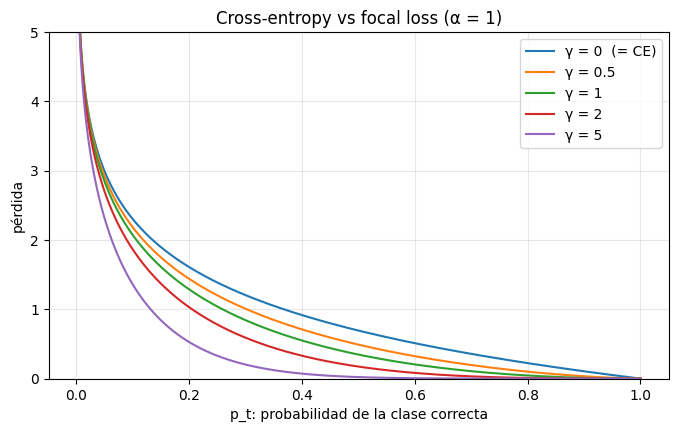

In [26]:
p_t = torch.linspace(0.001, 1, 500)
fig, ax = plt.subplots(figsize=(8, 4.5))
for gamma in (0, 0.5, 1, 2, 5):
    ax.plot(p_t, -(1 - p_t) ** gamma * torch.log(p_t), label=f"γ = {gamma}" + ("  (= CE)" if gamma == 0 else ""))
ax.set_xlabel("p_t: probabilidad de la clase correcta")
ax.set_ylabel("pérdida")
ax.set_ylim(0, 5)
ax.set_title("Cross-entropy vs focal loss (α = 1)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### Por qué importa: quién domina la pérdida total

Un detector de una etapa evalúa ~100 000 posiciones por imagen y casi todas son **fondo fácil**. Simulamos 100 000 anchors: 100 positivos (que el modelo todavía duda) y 99 900 negativos que ya clasifica bien.

pérdida                   de positivos  de negativos   % que aportan los negativos
Cross-entropy                   125.13       1616.68                         92.8%
Focal (γ=2, α=0.25)              18.37          3.99                         17.8%


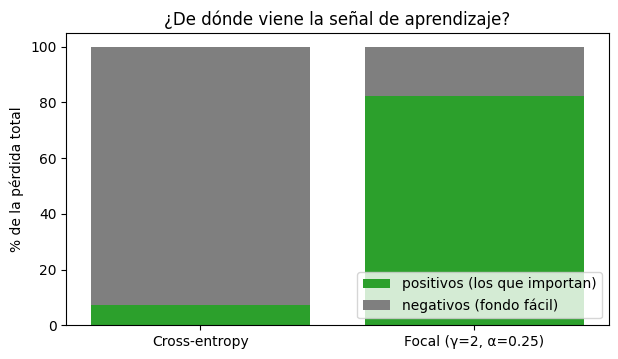

In [27]:
torch.manual_seed(0)
n_pos, n_neg = 100, 99_900
logits_pos = torch.randn(n_pos) * 1.0 - 0.8         # p ≈ 0.3  -> positivos "difíciles"
logits_neg = torch.randn(n_neg) * 1.0 - 4.6         # p ≈ 0.01 -> negativos "fáciles"

prob = torch.sigmoid(torch.cat([logits_pos, logits_neg]))
y = torch.cat([torch.ones(n_pos), torch.zeros(n_neg)])

print(f"{'pérdida':<24}{'de positivos':>14}{'de negativos':>14}{'% que aportan los negativos':>30}")
resultados = {}
for nombre, perdida in {"Cross-entropy": ce_binaria(prob, y),
                        "Focal (γ=2, α=0.25)": focal_loss(prob, y, 0.25, 2.0)}.items():
    lp, ln = perdida[:n_pos].sum().item(), perdida[n_pos:].sum().item()
    resultados[nombre] = (lp, ln)
    print(f"{nombre:<24}{lp:>14.2f}{ln:>14.2f}{100 * ln / (lp + ln):>29.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.8))
nombres = list(resultados)
lp = np.array([resultados[n][0] for n in nombres])
ln = np.array([resultados[n][1] for n in nombres])
ax.bar(nombres, 100 * lp / (lp + ln), label="positivos (los que importan)", color="tab:green")
ax.bar(nombres, 100 * ln / (lp + ln), bottom=100 * lp / (lp + ln), label="negativos (fondo fácil)", color="tab:gray")
ax.set_ylabel("% de la pérdida total"); ax.legend(loc="lower right")
ax.set_title("¿De dónde viene la señal de aprendizaje?")
plt.show()

Con CE, 99 900 negativos triviales aportan **la gran mayoría** de la pérdida y ahogan el gradiente de los 100 positivos que sí importan. La focal loss los silencia.

> **Ojo con el mito:** "YOLO usa focal loss" es falso. Focal loss es de **RetinaNet** (y de la clasificación de DETR); el linaje Ultralytics YOLO usa BCE y resuelve el desbalance con la asignación de etiquetas.

## 6.2 Regresión de cajas

### Smooth L1 vs L2

Con L2 (MSE) el gradiente crece **linealmente** con el error: un solo caso muy mal predicho domina el batch. Smooth L1 es cuadrática cerca del cero y **lineal** lejos, así que su gradiente queda acotado.

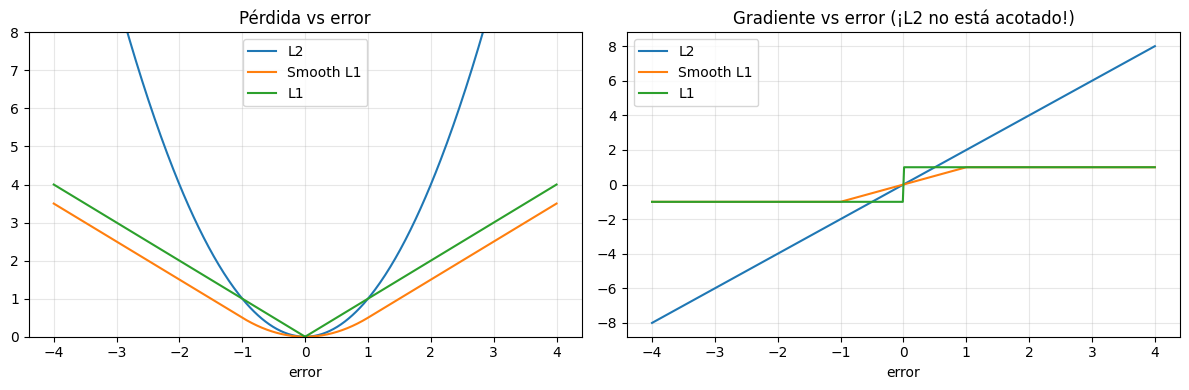

In [28]:
x = torch.linspace(-4, 4, 400, requires_grad=True)
l2 = x ** 2
sl1 = F.smooth_l1_loss(x, torch.zeros_like(x), beta=1.0, reduction="none")
l1 = x.abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, perdida in (("L2", l2), ("Smooth L1", sl1), ("L1", l1)):
    g, = torch.autograd.grad(perdida.sum(), x, retain_graph=True)
    axes[0].plot(x.detach(), perdida.detach(), label=nombre)
    axes[1].plot(x.detach(), g, label=nombre)
axes[0].set_title("Pérdida vs error"); axes[1].set_title("Gradiente vs error (¡L2 no está acotado!)")
for ax in axes:
    ax.set_xlabel("error"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylim(0, 8)
plt.tight_layout()
plt.show()

### La familia IoU: IoU → GIoU → DIoU → CIoU

Las pérdidas L1 / L2 / Smooth L1 tratan las 4 coordenadas como números sueltos, sin noción de superposición. La familia IoU optimiza directamente lo que se evalúa:

| Pérdida | Fórmula | Qué agrega |
|---|---|---|
| **IoU** | `1 − IoU` | optimiza el solapamiento |
| **GIoU** | `1 − (IoU − (\|C\| − \|A∪B\|)/\|C\|)` | penaliza el área vacía de la caja envolvente `C`, así que hay gradiente **sin solapamiento** |
| **DIoU** | `1 − (IoU − ρ²/c²)` | penaliza la distancia entre centros (`ρ`) sobre la diagonal de `C` (`c`) |
| **CIoU** | `1 − (IoU − ρ²/c² − α·v)` | suma consistencia de **aspect ratio**, con `v = 4/π²·(arctan(w_gt/h_gt) − arctan(w/h))²` y `α = v / ((1−IoU) + v)` |

Las implementamos vectorizadas y las verificamos contra `torchvision`.

In [29]:
def perdidas_iou(pred, gt, eps=1e-7):
    """Pérdidas IoU, GIoU, DIoU y CIoU para cajas xyxy emparejadas (N, 4). Devuelve un dict de tensores (N,)."""
    wp, hp = pred[:, 2] - pred[:, 0], pred[:, 3] - pred[:, 1]
    wg, hg = gt[:, 2] - gt[:, 0], gt[:, 3] - gt[:, 1]

    # IoU
    iw = (torch.minimum(pred[:, 2], gt[:, 2]) - torch.maximum(pred[:, 0], gt[:, 0])).clamp(min=0)
    ih = (torch.minimum(pred[:, 3], gt[:, 3]) - torch.maximum(pred[:, 1], gt[:, 1])).clamp(min=0)
    inter = iw * ih
    union = wp * hp + wg * hg - inter
    iou = inter / (union + eps)

    # Caja envolvente C
    cw = torch.maximum(pred[:, 2], gt[:, 2]) - torch.minimum(pred[:, 0], gt[:, 0])
    ch = torch.maximum(pred[:, 3], gt[:, 3]) - torch.minimum(pred[:, 1], gt[:, 1])
    area_c = cw * ch
    giou = iou - (area_c - union) / (area_c + eps)

    # Distancia entre centros al cuadrado / diagonal de C al cuadrado
    rho2 = ((pred[:, 0] + pred[:, 2] - gt[:, 0] - gt[:, 2]) ** 2 + (pred[:, 1] + pred[:, 3] - gt[:, 1] - gt[:, 3]) ** 2) / 4
    diou = iou - rho2 / (cw ** 2 + ch ** 2 + eps)

    # Consistencia de aspect ratio
    v = (4 / math.pi ** 2) * (torch.atan(wg / (hg + eps)) - torch.atan(wp / (hp + eps))) ** 2
    with torch.no_grad():                       # α actúa como compuerta: no recibe gradiente
        alfa = v / ((1 - iou) + v + eps)
    ciou = diou - alfa * v

    return {"IoU": 1 - iou, "GIoU": 1 - giou, "DIoU": 1 - diou, "CIoU": 1 - ciou}


# Verificación contra torchvision con cajas aleatorias (¡con distinto aspect ratio a propósito!)
xy = torch.rand(200, 2) * 100
pred = torch.cat([xy, xy + 10 + torch.rand(200, 2) * 80], dim=1)
xy = torch.rand(200, 2) * 100
gt = torch.cat([xy, xy + 10 + torch.rand(200, 2) * 80], dim=1)

mias = perdidas_iou(pred, gt)
lib = {"IoU": 1 - box_iou(pred, gt).diag(),
       "GIoU": 1 - torchvision.ops.generalized_box_iou(pred, gt).diag(),
       "DIoU": 1 - torchvision.ops.distance_box_iou(pred, gt).diag(),
       "CIoU": 1 - torchvision.ops.complete_box_iou(pred, gt).diag()}
for nombre in mias:
    print(f"{nombre}: coincide con torchvision -> {torch.allclose(mias[nombre], lib[nombre], atol=1e-4)}")

IoU: coincide con torchvision -> True
GIoU: coincide con torchvision -> True
DIoU: coincide con torchvision -> True
CIoU: coincide con torchvision -> True


### 6.2.1 Cuándo muere la pérdida IoU

Fijamos un objeto real y **deslizamos una predicción de la misma forma** de izquierda a derecha, de muy lejos a superpuesta. Miramos cómo se comporta cada pérdida:

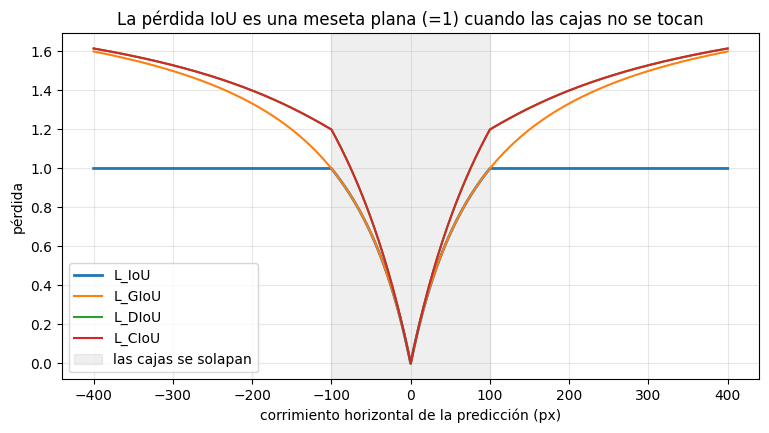

desplazada 150 px -> L_IoU=1.0000 | L_GIoU=1.2000 | L_DIoU=1.3103 | L_CIoU=1.3103
desplazada 300 px -> L_IoU=1.0000 | L_GIoU=1.5000 | L_DIoU=1.5294 | L_CIoU=1.5294
desplazada 600 px -> L_IoU=1.0000 | L_GIoU=1.7143 | L_DIoU=1.7200 | L_CIoU=1.7200


In [30]:
gt_fijo = torch.tensor([[100., 100., 200., 200.]])
offsets = torch.linspace(-400, 400, 401)                 # corrimiento horizontal de la predicción
pred_mov = gt_fijo.repeat(len(offsets), 1)
pred_mov[:, [0, 2]] += offsets[:, None]

curvas = perdidas_iou(pred_mov, gt_fijo.repeat(len(offsets), 1))

fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre, valores in curvas.items():
    ax.plot(offsets, valores, label=f"L_{nombre}", lw=2 if nombre == "IoU" else 1.5)
ax.axvspan(-100, 100, color="gray", alpha=0.12, label="las cajas se solapan")
ax.set_xlabel("corrimiento horizontal de la predicción (px)")
ax.set_ylabel("pérdida")
ax.set_title("La pérdida IoU es una meseta plana (=1) cuando las cajas no se tocan")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

for off in (150, 300, 600):
    pr = gt_fijo.clone(); pr[:, [0, 2]] += off
    l = perdidas_iou(pr, gt_fijo)
    print(f"desplazada {off:>3} px -> " + " | ".join(f"L_{k}={v.item():.4f}" for k, v in l.items()))

Fuera de la zona gris, `L_IoU` vale **exactamente 1** tan cerca como tan lejos: no distingue "casi le pego" de "está en la otra punta de la imagen". Las otras siguen creciendo con la distancia.

### 6.2.2 Consecuencia: ¿aprende el modelo? Descenso por gradiente sobre la caja

Tratamos las coordenadas de la predicción como **parámetros** y las optimizamos con Adam contra cada pérdida, arrancando desde una caja disjunta. Es un modelo de juguete de lo que pasa en el entrenamiento cuando la predicción inicial falla al objeto:

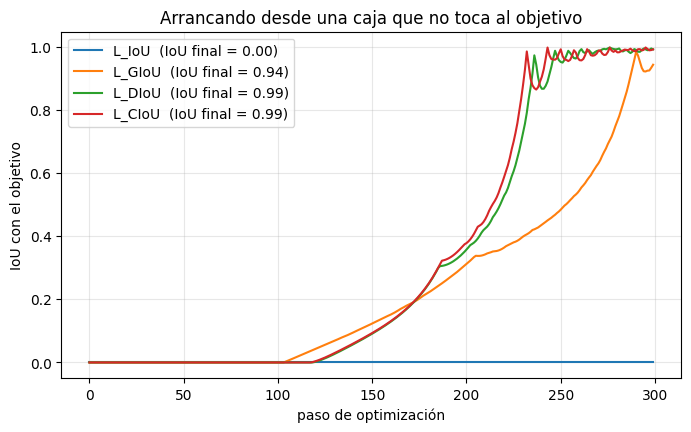

In [31]:
def optimizar_caja(nombre_perdida, inicio, objetivo, pasos=300, lr=1.0):
    """Optimiza las 4 coordenadas de una caja contra una pérdida. Devuelve la historia de IoU real."""
    caja = inicio.clone().requires_grad_(True)
    opt = torch.optim.Adam([caja], lr=lr)
    historia = []
    for _ in range(pasos):
        opt.zero_grad()
        perdidas_iou(caja, objetivo)[nombre_perdida].sum().backward()
        opt.step()
        historia.append(box_iou(caja.detach(), objetivo).item())       # medimos siempre con IoU, sea cual sea la pérdida
    return historia


inicio = torch.tensor([[300., 100., 400., 200.]])           # disjunta: 100 px a la derecha del objetivo

fig, ax = plt.subplots(figsize=(8, 4.5))
for nombre in ("IoU", "GIoU", "DIoU", "CIoU"):
    hist = optimizar_caja(nombre, inicio, gt_fijo)
    ax.plot(hist, label=f"L_{nombre}  (IoU final = {hist[-1]:.2f})")
ax.set_xlabel("paso de optimización"); ax.set_ylabel("IoU con el objetivo")
ax.set_title("Arrancando desde una caja que no toca al objetivo")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

La pérdida IoU **no se mueve del lugar**: el gradiente es cero, Adam no tiene nada que seguir y la caja queda clavada. GIoU, DIoU y CIoU se acercan al objetivo y convergen. Esa meseta es exactamente el motivo por el que existen.

## Cierre

| Pieza | Idea para llevarse |
|---|---|
| **IoU** | es la moneda común: asignación, NMS, métricas y pérdidas |
| **Anchors** | referencias fijas; la red aprende *offsets normalizados*. La regla max-IoU evita que un objeto chico quede sin positivos |
| **Anchor-free** | reemplaza anchors por distancias `(l, t, r, b)`, pero igual necesita una regla de asignación |
| **RoI Align** | sin cuantización: salida continua frente a desplazamientos sub-celda |
| **NMS** | deduplica; debe correr **por clase**, y el umbral es un hiperparámetro |
| **Accuracy vs recall/F1** | con clases desbalanceadas el accuracy engaña |
| **mAP** | AP por clase con todas las imágenes juntas; mAP@[50:95] premia cajas ajustadas |
| **Focal loss** | apaga los negativos fáciles que ahogan el gradiente |
| **IoU → CIoU** | cada pérdida arregla un punto ciego de la anterior |

---
# Ejercicios

## Ejercicio 1: Umbrales de asignación de anchors

Usando `anchors`, `gts` y `asignar_anchors` de la Sección 2.2, contá cuántos anchors quedan **positivos / negativos / ignorados** con estas tres configuraciones, **sin** la regla max-IoU (`usar_max_iou=False`):

| Detector | `umbral_pos` | `umbral_neg` |
|---|---|---|
| RPN de Faster R-CNN | 0.7 | 0.3 |
| RetinaNet | 0.5 | 0.4 |
| Segunda etapa de Faster R-CNN | 0.5 | 0.5 |

Después repetí con `usar_max_iou=True`.

Responder: ¿En cuál configuración hay más anchors ignorados? ¿Qué le pasa al objeto chico en cada caso, con y sin max-IoU? ¿Qué implicancia tiene para un dataset con muchos objetos pequeños?

In [32]:
# Ejercicio 1: Completar aquí

configuraciones = {
    "RPN (0.7 / 0.3)":       (0.7, 0.3),
    "RetinaNet (0.5 / 0.4)": (0.5, 0.4),
    "2da etapa (0.5 / 0.5)": (0.5, 0.5),
}

# for usar_max_iou in (False, True):
#     for nombre, (umbral_pos, umbral_neg) in configuraciones.items():
#         etiquetas, gt_idx, _ = ...  # TODO: llamar a asignar_anchors con estos umbrales
#         # TODO: contar positivos (1), negativos (0) e ignorados (-1)
#         # TODO: contar cuántos positivos tiene el objeto chico (gt_idx == 1)
#         print(...)

## Ejercicio 2: Soft-NMS

Con NMS clásico, dos objetos **realmente distintos pero muy juntos** (una multitud) pueden ser borrados porque sus cajas se superponen. **Soft-NMS** no elimina la caja: le **reduce el score** según cuánto se superpone con la que ganó. Con la variante gaussiana:

$$s_i \leftarrow s_i \cdot e^{-\mathrm{IoU}(M, b_i)^2 / \sigma}$$

donde `M` es la caja de mayor score en la ronda actual.

**Pasos:**
1. Implementar `soft_nms(cajas, scores, sigma=0.5, umbral_score=0.3)`: en cada ronda tomar la caja de mayor score, guardarla, decaer los scores del resto y descartar las que queden por debajo de `umbral_score`.
2. Aplicarla al ejemplo de abajo (tres personas en una multitud, con IoU ≈ 0.5-0.6 entre vecinas) y compararla con `nms` de torchvision a umbral 0.5.

Responder: ¿Cuántas detecciones conserva cada método? ¿En qué situaciones preferirías uno u otro? ¿Qué hace el parámetro `sigma`?

In [33]:
# Ejercicio 2: Completar aquí

multitud = torch.tensor([[50., 40., 110., 160.],
                         [70., 42., 130., 162.],
                         [90., 38., 150., 158.]])      # tres personas hombro con hombro
scores_multitud = torch.tensor([0.92, 0.88, 0.85])


def soft_nms(cajas, scores, sigma=0.5, umbral_score=0.3):
    """Soft-NMS gaussiano. Devuelve (cajas, scores) de las detecciones que sobreviven."""
    cajas, scores = cajas.clone(), scores.clone()
    conservadas, scores_finales = [], []
    while len(scores) > 0:
        i = int(scores.argmax())
        # TODO: guardar la caja i y su score
        # TODO: calcular el IoU de la caja i contra el resto (usá iou_matriz)
        # TODO: decaer los scores del resto con la gaussiana
        # TODO: sacar la caja i y las que quedaron por debajo de umbral_score
        break
    raise NotImplementedError("completar soft_nms")


# print("NMS clásico:", nms(multitud, scores_multitud, 0.5).tolist())
# cajas_soft, scores_soft = soft_nms(multitud, scores_multitud)
# print("Soft-NMS   :", len(cajas_soft), "detecciones con scores", scores_soft.tolist())

## Ejercicio 3: Mejor umbral de score con la curva PR

`ap_una_clase` devuelve para cada clase las curvas `precision`, `recall` y los `scores` de las detecciones **ordenadas de mayor a menor score**. Cada punto de la curva corresponde a un posible **umbral de confianza** (quedarse con las detecciones hasta ese punto).

**Pasos:**
1. Para la clase 0 con IoU 0.5, calcular el `F1` en cada punto de la curva.
2. Encontrar el punto de F1 máximo y el **umbral de score** que le corresponde.
3. Graficar la curva PR y marcar ese punto.
4. Repetir para IoU 0.75 y comparar.

Responder: ¿Cómo cambia el mejor umbral de score al exigir un IoU más alto? ¿Por qué el AP no depende de elegir un umbral de score, pero un sistema en producción sí necesita elegir uno?

In [34]:
# Ejercicio 3: Completar aquí

# for umbral_iou in (0.5, 0.75):
#     r = ap_una_clase(preds, gts_det, clase=0, umbral_iou=umbral_iou)
#     precision, recall, scores = r["precision"], r["recall"], r["scores"]
#
#     # TODO: f1 = ... (2 * P * R / (P + R)), cuidando la división por cero
#     # TODO: k = índice del F1 máximo
#     # TODO: imprimir F1 máximo, umbral de score = scores[k], precision y recall en ese punto
#     # TODO: graficar recall vs precision y marcar el punto k

## Ejercicio 4: Cajas anidadas, donde GIoU se queda sin señal

Cuando una caja está **completamente dentro** de la otra, la caja envolvente `C` coincide con la mayor de las dos y el término de penalización de GIoU se anula: **GIoU = IoU**. DIoU, en cambio, sigue viendo la distancia entre centros.

**Pasos:**
1. Con `gt = [100, 100, 200, 200]` y una predicción anidada y descentrada `pred = [110, 110, 150, 150]`, calcular con `perdidas_iou` las cuatro pérdidas. Verificar que `L_GIoU == L_IoU`.
2. Calcular la norma del gradiente respecto de las coordenadas de la predicción para `L_IoU`, `L_GIoU` y `L_DIoU` (usá `requires_grad_(True)` y `.backward()`).
3. Optimizar la caja con `optimizar_caja` y contar **cuántos pasos** necesita cada pérdida para llegar a IoU ≥ 0.9.

Responder: ¿Por qué GIoU se degenera en este caso? ¿Cuál converge más rápido y por qué? ¿Qué aporta CIoU cuando además la forma no coincide?

In [35]:
# Ejercicio 4: Completar aquí

gt_anidado = torch.tensor([[100., 100., 200., 200.]])
pred_anidada = torch.tensor([[110., 110., 150., 150.]])

# 1. Las cuatro pérdidas
# TODO: l = perdidas_iou(pred_anidada, gt_anidado); imprimir y comparar L_GIoU con L_IoU

# 2. Norma del gradiente por pérdida
# for nombre in ("IoU", "GIoU", "DIoU"):
#     p = pred_anidada.clone().requires_grad_(True)
#     # TODO: perdidas_iou(p, gt_anidado)[nombre].sum().backward()
#     # TODO: imprimir p.grad.abs().sum()

# 3. Pasos hasta IoU >= 0.9
# for nombre in ("IoU", "GIoU", "DIoU", "CIoU"):
#     hist = optimizar_caja(nombre, pred_anidada, gt_anidado, pasos=300)
#     # TODO: primer paso en el que hist >= 0.9 (o "nunca")